In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import evt_module as evt

*Acknowledgments: This notebook borrows material from a textbook from Stuart Coles (2001) and notebooks from Jorn Mossel and Climematch. Finally, trend detection follows the work of World Weather Attribution to Malacca Strait.*

# Problem Introduction

At the end of November 2025, Sumatra was devastated by exceptional monsoon rains and a rare tropical storm by Cyclone Senyar. This triggers massive flooding, flash floods, and widespread landslides across provinces with more than 3.2–3.3 million people have been affected. Given the high impact damage, we might ask **is such an extreme event statistically to happen once in a while** or **is this an indication of a changing climate**?

## Preparing the Data

We will be using ERA5 daily data over defined this defined region. 

<img src="../../output/project/domain.png" width="550">

We will use area-averaged Rx5day which can be easily computed using CDO commands. We define water cycle starting from June to July.

```
cdo fldmean era_tp_sumatra.nc era5_tp_sumatra_fldmean.nc
cdo shifttime,6mon -yearmax -runsum,5 -shifttime,-6mon era5_tp_sumatra_fldmean.nc rx5day_sumatra.nc
```

In [2]:
# Open file for Rx5day
ds = xr.open_dataset("../../data/era5_daily_tp/rx5day_sumatra.nc")

# Take precipitation variable and convert unit
pr = ds['tp'] * 1_000

# Convert to DataFrame
df = pr.to_dataframe().reset_index()[['valid_time', 'tp']]
df = df[1:] # remove first row (shift excess)
df['year'] = df['valid_time'].dt.year
df = df.set_index(keys='year')

# Read GMST data
df_gmst = pd.read_csv(
    "../../data/covariate/gmst.dat",
    comment="#",            # ignore lines starting with '#'
    sep=r'\s+',              # split on any whitespace
    header=None,            # no header row in the data
    names=["year", "gmst"]
    )
df_gmst = df_gmst.set_index(keys='year')

# Merge data to one DataFrame
df = pd.merge(df, df_gmst, left_index=True, right_index=True)

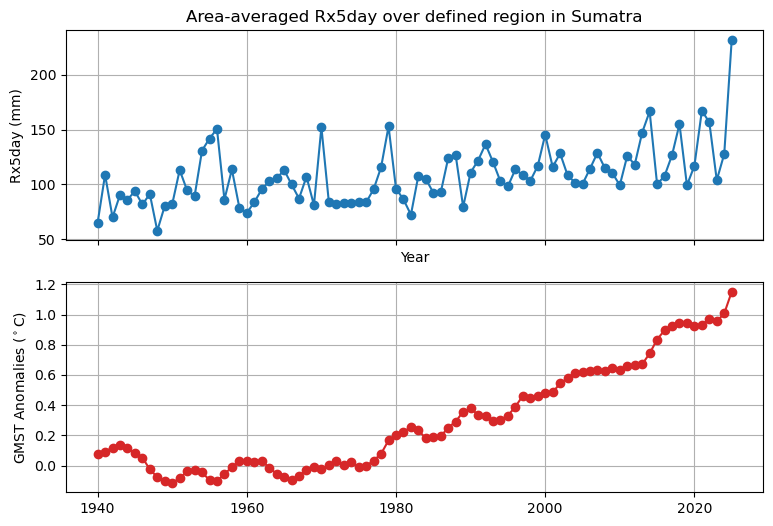

In [3]:
# Prepare axis
fig, ax = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

# Plot Rx5day
ax[0].plot(df.index, df['tp'], '-o')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Rx5day (mm)')
ax[0].set_title('Area-averaged Rx5day over defined region in Sumatra')
ax[0].grid()

# Plot GMST
ax[1].plot(df.index, df['gmst'], '-o', color='tab:red')
ax[1].set_ylabel(r'GMST Anomalies (${}^\circ$C)')
plt.grid()
plt.show()

# What is an extreme event?

## Defining empirical return levels
Engineers and policy makers tend to use something called the **$X$-year event**. For example, the new drainage system can stand a 50-year rainfall. The terminology **$X$-year return level** means a value that is expected **to be exceeded** exactly once in the next $X$ years.

Another example: The 100-year event has a 1% change of happening each year, meaning you expect to see at least one 100-year event every 100 years.

Empirically, we can derive this from our observation. Let $Z$ denotes the distribution of Rx5day annual maxima. Given ordered yearly maximum data $z_{(1)} \leq z_{(2)} \leq ... \leq z_{(m)}$, the probability of exceeding a value with rank $i$ data is
$$
P(Z > z_{(i)}) = 1 - P(Z \leq z_{(i)}) = 1 - i/(m+1)
$$
which corresponds to the the return year of $1/P(Z > z_{(i)})$.

Let's apply this definition to our annual Rx5day time series. Frequently, we discuss return periods using a logarithmic scale, referring to events with return periods of 1 year, 10 years, and 100 years.

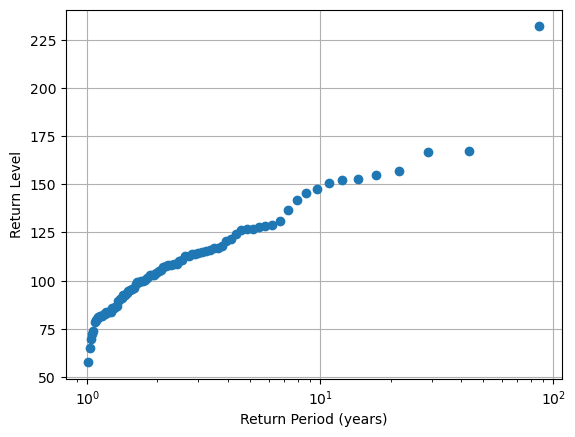

In [3]:
_, ax = plt.subplots()
evt.plot_empirical_return_level(df['tp'].values, ax)
evt.decorate_return_level_plot(ax)
plt.show()

## Uncertainty in empirical return level

A small change in the data series can have large consequences for the computation of return levels and return periods, especially for very rare events. For example, let's say we replace the recent extreme event in 2025 (the highest record) with a "common" annual maxima. Note that it's becoming uncertain to estimate the 100-year event by comparing both plots.

In [4]:
# Creating fake time series
df_fake = df.copy()
# Replace 2025 event with median of the annual maxima to represent a common value
df_fake.loc[2025, 'tp'] = np.median(df['tp'])

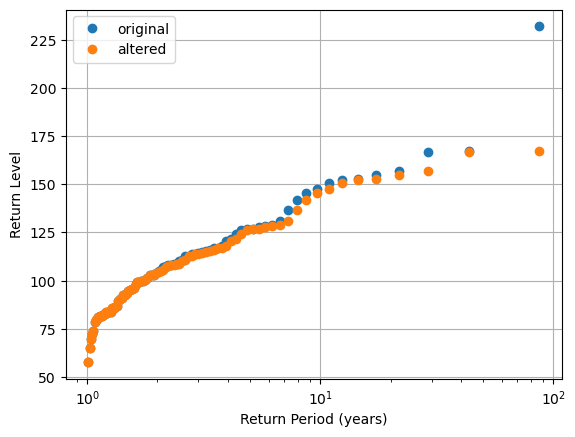

In [5]:
_, ax = plt.subplots()
ax = evt.plot_empirical_return_level(df['tp'].values, ax, label='original')
ax = evt.plot_empirical_return_level(df_fake['tp'].values, ax, label='altered', color='tab:orange')
evt.decorate_return_level_plot(ax, activate_legend=True)
plt.show()

Fortunately, there is a trick that allows us to use the data itself to tell us about its own uncertainty. This method is called **bootstrapping**, in reference to the saying of “pulling oneself up by one’s bootstraps”.

This method works by assuming that while we have limited data, the data that we do have is nevertheless a representative sample of possible events - that is we assume that we did not miss anything systematic. Then, we use the data as a distribution to resample from, and compute uncertainties using those:

1. We draw artificial observations from our data - with replacement.
2. We draw as many observations as our data record is long. This record will now only include data points that we observed before, but some will show up several times, some not at all.
3. We compute our statistics over this artifical record - just as we did to the record itself.
4. We repeat this process many times.
5. Thus we compute our statistics over many artificial records, which can give us an indication of the uncertainty.

By resampling data from our observation, we also call this **non-parametric bootstrap** method.

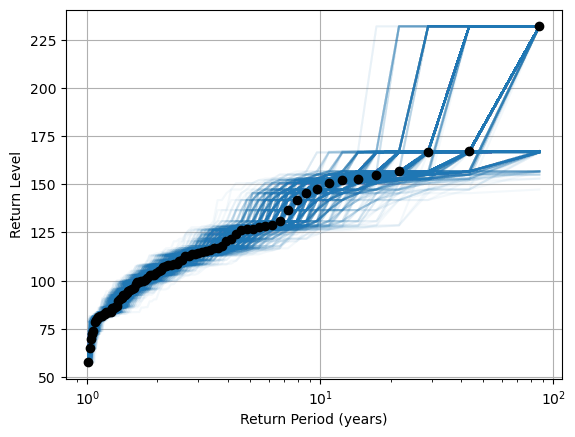

In [6]:
# Number of experiments
n_boot = 1_000

# Initialize plot
_, ax = plt.subplots()

# Perform experiments
for _ in range (n_boot):
    # Draw data
    resample = np.random.choice(df['tp'].values, size=len(df['tp'].values), replace=True)
    # Plot
    ax = evt.plot_empirical_return_level(resample, ax, marker='-', alpha=0.05)

# Plot original return levels
ax = evt.plot_empirical_return_level(df['tp'].values, ax, color='k')

# Decorate plot
evt.decorate_return_level_plot(ax)
plt.show()

# Introduction to Extreme Value Theory

Empirical return values are not enough. We often need extrapolation and address the uncertainty from empirical return levels. Instead we can use **extreme value theory**, to fit a statistical distribution for extreme observations only. Not only is this method more robust it also allows us to do extrapolation. For example if we have only 100 years of data we can still use the fitted distribution to make predictions of what a 200 years event would be.

# GEV Distribution

Extreme Value Theory is the statistical study of extreme deviations (ie tail events). For example, stock market crashes, 100-year flood events etc.

The classical Extreme Value Theory approach is to study the statistics of *block maxima*
$$M_n = \max (X_1, \ldots, X_n)$$
where $X_i$ are iid random variables with a common distrubtion function $F$. For many applications the distribution $F$ is unknown. However, in a similar spirit as the **Central Limit Theorem**, which that in many situations the (standardized) sum of iid random variables approaches a normal distribution, the block maxima apporaches a different limit distribution.

## Fisher–Tippett–Gnedenko theorem (limit theory for block maxima)
Suppose that there exists two sequences of real numbers $\{a_n\}$ and $\{b_n\}$ such that following limit converages to a limiting distribtion
$$
\lim_{n\rightarrow \infty} P((M_n - b_n)/a_n \leq z) = G(z)
$$
the CDF $G(z)$ is the so-call *Generalized Extreme Value (GEV)* distribution
$$
G(z) = \exp\left( -(1+\xi z)^{-1/\xi} \right)
$$ 
with $z = (x-\mu)/\sigma$.

This is a powerful theorem. It tells us that when we want to model extreme events via block maxima we can describe it with the GEV distribution. Full knowledge of the probablity distribution of the underlying random variables $X_i$ is not required.

## Chosing the size of block maxima (*trade-off between bias and variance*)
While the theorem is strictly only valid in the limit $n \rightarrow \infty$ in reality we want to chose an $n$ 
small enough to have sufficiently data but large enough so that the GEV approximation is accurate. In practice for many applications that experience seasonality, the size of block maxima is the number of observations per year. In other words, for each year we take maximum observed value, and these are 
fitted to a GEV distribtion.

## Maximum Likelihood Estimation
Under the assumption that $Z_1, ..., Z_m$ are independent variables having the GEV distribution, the log-likelihood for the GEV parameters when $\xi \neq 0$ is
$$
\ell(\mu,\sigma,\xi) = -m \log{\sigma} - (1 + 1/\xi) \sum_{i=1}^m \log{\left[1 + \xi \left(\frac{z_i - \mu}{\sigma} \right) \right]} - \sum_{i=1}^m \left[ 1 + \xi \left( \frac{z_i - \mu}{\sigma} \right) \right]^{-1/\xi}
$$
provided that
$$
1 + \xi \left( \frac{z_i - \mu}{\sigma} \right) > 0, \text{for } i=1,...,m.
$$

The case $\xi=0$ requires separate treatment using the Gumbel limit of the GEV distribution, leading to
$$
\ell(\mu,\sigma) = -m \log{\sigma} - \sum_{i=1}^m \left( \frac{z_i - \mu}{\sigma} \right) - \sum_{i=1}^m \exp{\left\{- \left( \frac{z_i - \mu}{\sigma} \right) \right\} }.
$$

We define estimated distribution parameters, $\hat{\mu}, \hat{\sigma}, \hat{\xi}$, as the solution to maximize $\ell(\mu, \sigma, \xi)$ given their respective domain. In my module, I used `scipy.minimize` method to solve this numerically.

## Return Levels
Given the maximum likelihood estimates of the GEV parameters, the maximum likelihood estimate of $z_p$ for $0 < p < 1$, the $1/p$ return level, is obtained by inverting the GEV distribution function as
$$
\hat{z_p} = 
\begin{cases}
\hat{\mu} - \frac{\hat{\sigma}}{\hat{\xi}}\left[ 1 - y_p^{\hat{\xi}} \right] \\
\hat{\mu} - \hat{\sigma} \log{\hat{y_p}}
\end{cases}
$$
where $y_p = -\log{(1-p)}$.

## Model Check
Given ordered block maximum data $z_{(1)} \leq z_{(2)} \leq ... \leq z_{(m)}$, the emprical distribution function evaluated at $z_{(i)}$ is given by
$$
\tilde{G(z_{(i)})} = i/(m+1)
$$
while the corresponding model-based estimates are
$$
\hat{G(z_{(i)})} = \exp{ \left\{ - \left[ 1 + \hat{\xi} \left(\frac{z_{(i)} - \hat{\mu}}{\hat{\sigma}}\right) \right]^{-1/\hat{\xi}}  \right\} }
$$

If the GEV model is working well,
$$
\tilde{G(z_{(i)})} \approx \hat{G(z_{(i)})}
$$.

Another way to assess this is using quantile plot consiting of the points
$$
\left\{ \left(\hat{G}^{-1}(1/(m+1)), z_{(i)} \right), i=1, ..., m \right\}
$$
with
$$
\hat{G}^{-1}\left( \frac{i}{m+1} \right) = \hat{\mu} - \frac{\hat{\sigma}}{\hat{\xi}} \left[ 1 - \left\{ -\log{\left(\frac{i}{m+1}\right)}^{-\hat{\xi}} \right\} \right]. 
$$

Now, let's apply the theories to perform GEV fit to our Rx5day time series. Uncertainty analysis is performed by non-parametric bootstrap. We collect the distribution parameters from each resample. Then, we can compute the sample mean of each parameter. Confidence interval of 95% is constructed by taking the 2.5% and 97.5% quantiles of the parameters.  

# Stationary Fit

In [9]:
# Perform GEV fit with bootstrap method
params_stationary = evt.gev_fit_with_bootstrap(df['tp'].values)

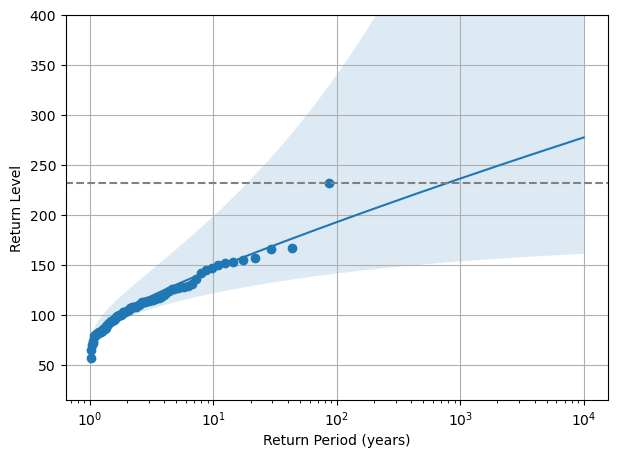

In [9]:
# Plot return level
ax = evt.plot_empirical_return_level(df['tp'].values)
evt.plot_fit_return_level(params_stationary[0], ax, rp_max=1e4)
evt.plot_confidence_interval(params_stationary[1], params_stationary[2], ax, rp_max=1e4)
evt.decorate_return_level_plot(ax)

# Add 2025 event line
ax.hlines(df['tp'].loc[2025], 0, 1e5, linestyles='--', color='gray')

ax.set_ylim(None, 400)
plt.show()

We diagnose the fitness of our model comparing the empirical and fitted quantiles. If it's a good fit, we expect the quantiles to follow a linear 1:1 line.

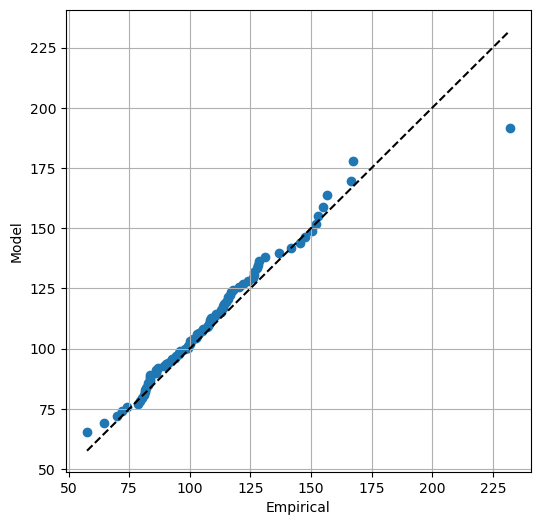

In [7]:
evt.plot_qq(df['tp'].values, params_stationary[0])
plt.show()

# Non-Stationary Fit

So far, we performed analysis under stationary assumption: the distribution parameters don't change over time. However, under the warming climate, we know this is an unlikely assumption. For instance, we have the knowledge that precipitation scale exponentially with temperature, following the Claysius-Clapeyron relation.

We will now apply **non-stationary GEV** distribution to model the Rx5day time series. To model temperature effect on Rx5day, we define the Rx5day in year $t$ as
$$
Z_t \sim GEV(\mu(t), \sigma(t), \xi)
$$
with
$$
\mu(t) = \mu_0 \exp{\left( \alpha T(t) \right)}
$$
and
$$
\sigma(t) = \sigma_0 \exp{\left( \alpha T(t) \right)}
$$

where $\mu_0, \sigma_0$, and $\xi$ are the location, scale, and shape parameters of the distribution; $T$ is smoothed global mean surface temperature (GMST), and $\alpha$ is the trend due to GMST. Here, we refer GMST as a **covariate**.

We will again apply maximum likelihood estimation to fit $\mu_0, \sigma_0, \xi, \alpha$. 

> **Trend Detection:**
> When the confidence interval for $\alpha$ is above zero, we conclude that the GMST has a significant effect on Rx5day.

Let's now perform the non-stationary GEV fit with bootstrap method. Now, the resampling is done not only on the Rx5day data, but the paired data of Rx5day and its corresponding GMST anomaly.

In [3]:
# Perform non-stationary GEV fit with bootstrap method
params_nonstat = evt.gev_fit_gmst_with_bootstrap(df['tp'].array, df['gmst'].array)

/home/nathasya/.cache/pypoetry/virtualenvs/data-analysis-0gE2FHoP-py3.12/lib/python3.12/site-packages/pandas/core/arrays/numpy_.py:240: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/nathasya/.cache/pypoetry/virtualenvs/data-analysis-0gE2FHoP-py3.12/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]


Here, we print the values for $\alpha$, respectively its mean, lower, and upper estimate. We conclude that GMST has a significant effect on Rx5day.

In [4]:
print([params[3] for params in params_nonstat])

[np.float64(0.37375992587839757), np.float64(0.23767514712032137), np.float64(0.5152325425648517)]


Here we make plots to understand the trend.

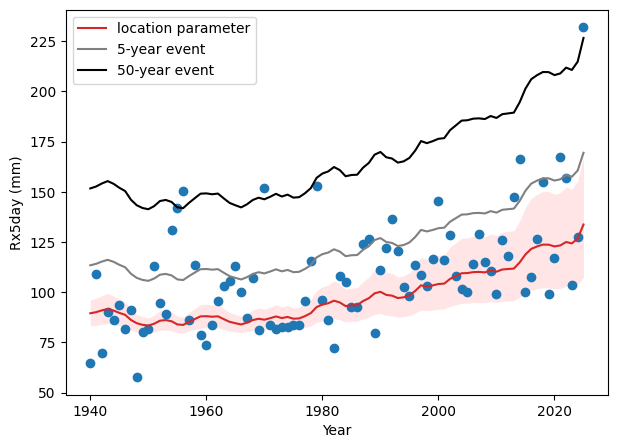

In [5]:
# Plot observed data
ax = evt.plot_data_vs_time(df.index, df['tp'].values)

# Add location parameter
evt.plot_location_vs_time(df.index, df['gmst'].array, params_nonstat[0], ax=ax, label='location parameter')

# Add location parameter confidence interval
ax.fill_between(
    df.index,
    evt.update_mu(params_nonstat[1], df['gmst']),
    evt.update_mu(params_nonstat[2], df['gmst']),
    color='red',
    alpha=0.1,
    linewidth=0
                )

# Add event return level
ax.plot(
    df.index, evt.find_event(df['gmst'].array, 5, params_nonstat[0]), 
    label='5-year event', color='gray'
    )

ax.plot(
    df.index, evt.find_event(df['gmst'].array, 50, params_nonstat[0]), 
    label='50-year event', color='k'
    )

ax.legend()
plt.show()

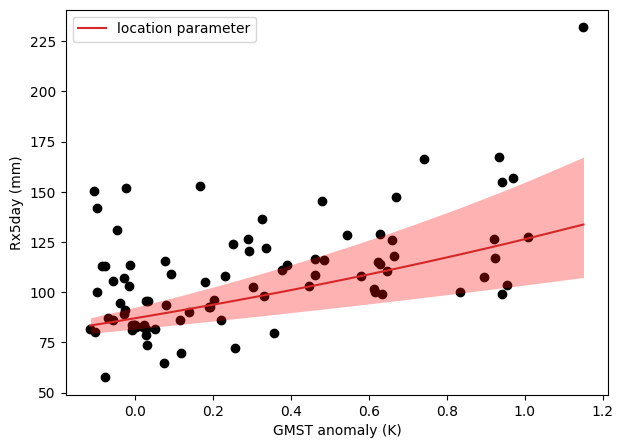

In [6]:
ax = evt.plot_data_vs_gmst(df['tp'], df['gmst'])
evt.plot_location_vs_gmst(df['gmst'], params_nonstat[0], ax=ax, label='location parameter')

# Add confidence interval
gmst_sorted = np.sort(df['gmst'])
ax.fill_between(
    gmst_sorted,
    evt.update_mu(params_nonstat[1], gmst_sorted),
    evt.update_mu(params_nonstat[2], gmst_sorted),
    color='red',
    alpha=0.3,
    linewidth=0
                )

ax.legend()
plt.show()

Again, we can create a QQ-plot to validate our model.

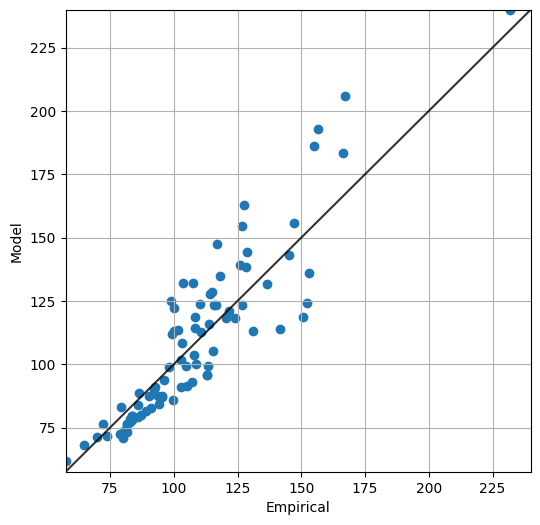

In [7]:
evt.plot_qq_nonstat(df['tp'].values, df['gmst'].values, params_nonstat[0])
plt.show()

Let's compare the likelihood between our stationary and nonstationary fit. The one with larger likelihood indicates a better fit.

In [10]:
ll_stat = -1 * evt.gev_negloglik(params_stationary[0], df['tp'].values)
ll_nonstat = -1 * evt.gev_negloglik_gmst(params_nonstat[0], df['tp'].values, df['gmst'].values)
print('Stationary fit likelihood :', ll_stat)
print('Non-stationary fit likelihood :', ll_nonstat)

Stationary fit likelihood : -397.6153039346834
Non-stationary fit likelihood : -382.2525933759299


# Trend Detection

Now, let's plot the return level corresponding to the GMST anomaly in 2025. Then, we compared it to a counterfactual climate where we assume GMST anomaly is zero.

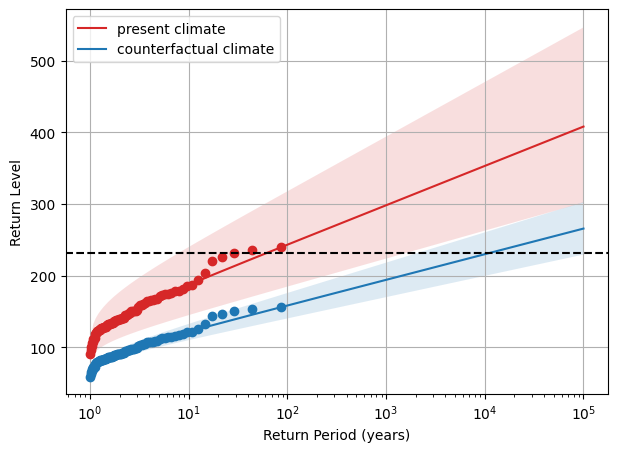

In [8]:
# Present climate
gmst_present = df['gmst'].iloc[-1]
ax = evt.plot_return_level_nonstat(df['tp'].values, df['gmst'].values, gmst_present, params_nonstat[0],
                               color='tab:red', label='present climate')
evt.plot_confidence_interval_nonstat(params_nonstat, gmst_present, color='tab:red', ax=ax)

# Counterfactual
gmst_counter = 0
evt.plot_return_level_nonstat(df['tp'].values, df['gmst'].values, gmst_counter, params_nonstat[0], ax=ax,
                               color='tab:blue', label='counterfactual climate')
evt.plot_confidence_interval_nonstat(params_nonstat, gmst_counter, color='tab:blue', ax=ax)

# Decorate plot
evt.decorate_return_level_plot(ax, activate_legend=True)

# Add line for 2025 event value
ax.hlines(df['tp'].iloc[-1], 0, 1e6, linestyle='--', color='k')
plt.show()

Define probability ratio
$$
PR = p_{\text{actual}} / p_{\text{counterfactual}}
$$
where $p_T$ describes the probability of the 2025 event being exceeded in the climate during GMST equals to $T$.
If the confidence interval on the PR excludes one (no change), the distribution is significantly different between the two climates.

In [ ]:
tp = df['tp'].loc[2025] # take latest event

print('Percentage change in likelihood for 2025 event respectively in lower bound, mean, and upper bound:')
for idx in [1, 0, 2]:
    pchange = evt.compute_probability_change(params_nonstat[idx], tp, gmst1=gmst_counter, gmst2=gmst_present)
    print(f'{pchange: .1f}')

Percentage change in likelihood for 2025 event respectively in lower bound, mean, and upper bound:
 74.2
 181.3
 259.9


The relative change in magnitude is assumed to be independent of magnitude, so it is expressed as a percentage change between the two climates:
$$
100 \left[ \exp{\alpha(T_{\text{actual}} - T_{\text{counterfactual}})} - 1\right]
$$

In [ ]:
print('Percentage change in magnitude for 2025 event respectively in lower bound, mean, and upper bound:')
for idx in [1, 0, 2]:
    #pchange = 100 * evt.compute_magnitude_change(params_nonstat[idx], gmst1=gmst_counter, gmst2=gmst_present)
    pchange = 100 * evt.compute_magnitude_change(params_nonstat[idx], tp, gmst1=gmst_counter, gmst2=gmst_present)
    print(f'{pchange: .1f}')

Percentage change in magnitude for 2025 event respectively in lower bound, mean, and upper bound:
 31.5
 53.5
 80.3


# Remarks

- The nonparametric bootstrap should be interpreted with caution because it leads to confidence intervals that are too narrow and underestimate the real uncertainties involved in the frequency models. ([Kyselý, 2008](https://doi.org/10.1175/2008JAMC1763.1))

- Trend is not attribution! It is important to note that detected trends may arise for a different reason than a change in global climate forcing. This can only be done with physical climate models that solve the physics of the climate system numerically dependent on the external forcing prescribed.